In [999]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

load_dotenv('../config/.env')  # reuse .env to prevent leak
os.getcwd()

'c:\\Users\\Alvin\\Music\\project_1\\notebook'

### A. Explaratory Data Analysis

In [1000]:
# Koneksi ke Postgres, baca langsung dari tabel marts hasil dbt
DB_USER = os.getenv("DB_USER", "alvin")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "price_intelligence")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

#Schema: 'public' fact table from mart
df_raw = pd.read_sql("SELECT * FROM public.fct_ebay_listings", engine)

print(f"Total baris: {len(df_raw)}")
df_raw.head()

Total baris: 2525


,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score,risk_category,volume_confidence
0,v1|115965603147|0,Spy Classroom Volumes 1-3 Light Novel Set New ...,56,10,USD,Brand New,US,True,False,False,False,40.5,13.5000,1.0,3.0,3.0,0,0,Low Risk,medium
1,v1|116204521440|0,"Spy Classroom, Vol. 7 (light novel): A Glint i...",79,15,USD,Brand New,US,False,False,False,False,17.2,17.2000,7.0,NaN,1.0,0,0,Low Risk,high
2,v1|116263745717|0,"Gimai Seikatsu, Days with My Step Sister Light...",80,13,USD,Brand New,MY,True,False,False,False,149.9,18.7375,1.0,8.0,8.0,70,0,High Risk,medium
3,v1|116267961169|0,The Eminence in Shadow 1-6 Novel English New H...,57,10,USD,Brand New,US,False,False,False,False,108.0,108.0000,NaN,NaN,1.0,0,0,Low Risk,low
4,v1|116268231670|0,"Bofuri: I Don't Want to Get Hurt, so I'll Max ...",79,17,USD,Brand New,US,False,False,False,False,17.2,17.2000,13.0,NaN,1.0,0,0,Low Risk,medium


#### A.1 Data Inspection

In [1001]:
df_raw.describe()

,title_length,title_word_count,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score
count,2525.000000,2525.000000,2525.000000,2525.000000,2112.000000,784.000000,2525.000000,2525.000000,2525.000000
mean,70.241188,11.739010,78.547881,28.205644,4.318182,16.095663,5.642376,14.998020,2.560396
std,11.941486,2.329359,109.978324,62.265922,5.104506,8.517979,8.391296,28.727123,6.947335
min,15.000000,3.000000,2.490000,0.302093,0.000000,1.000000,1.000000,0.000000,0.000000
25%,64.000000,10.000000,13.500000,10.518519,1.000000,11.000000,1.000000,0.000000,0.000000
50%,76.000000,12.000000,23.410000,14.990000,2.000000,13.000000,1.000000,0.000000,0.000000
75%,79.000000,13.000000,125.000000,22.290000,6.000000,26.000000,8.000000,0.000000,0.000000
max,80.000000,19.000000,1999.000000,1999.000000,29.000000,45.000000,45.000000,70.000000,30.000000


In [1002]:
missing_summary = df_raw.isnull().sum().to_frame('missing_count')
missing_summary['missing_%'] = (missing_summary['missing_count'] / len(df_raw) * 100).round(1)
missing_summary.sort_values('missing_count', ascending=False)

,missing_count,missing_%
volume_number_end,1741,69.0
volume_number,413,16.4
condition,28,1.1
item_id,0,0.0
title_word_count,0,0.0
title_length,0,0.0
title,0,0.0
currency,0,0.0
is_special_edition,0,0.0
boxset_side_story_edition_included,0,0.0


In [1003]:
print(f"risk_category distribution (all):{df_raw['risk_category'].value_counts()}")

df_price_model = df_raw[(df_raw['risk_category'] != 'High Risk') & (df_raw['volume_confidence'] != 'low')]
print(f"risk_category distribution (w/0 high risk & > low confidence): {df_price_model['risk_category'].value_counts()}")

risk_category distribution (all):risk_category
Low Risk     1984
High Risk     541
Name: count, dtype: int64
risk_category distribution (w/0 high risk & > low confidence): risk_category
Low Risk    1583
Name: count, dtype: int64


In [1004]:
df_raw[df_raw['is_special_edition'] == True].describe()

,title_length,title_word_count,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score
count,151.000000,151.000000,151.000000,151.000000,97.000000,9.000000,151.00000,151.000000,151.000000
mean,71.450331,11.807947,129.284503,110.864225,4.989691,20.888889,2.18543,1.390728,0.198675
std,9.818139,2.093530,202.242136,190.313300,4.536874,8.880378,5.15028,9.800662,1.720542
min,43.000000,6.000000,8.850000,8.850000,1.000000,2.000000,1.00000,0.000000,0.000000
25%,65.000000,10.000000,48.790000,46.495000,1.000000,17.000000,1.00000,0.000000,0.000000
50%,76.000000,12.000000,69.990000,66.070000,4.000000,26.000000,1.00000,0.000000,0.000000
75%,80.000000,13.000000,187.495000,110.000000,8.000000,26.000000,1.00000,0.000000,0.000000
max,80.000000,17.000000,1999.000000,1999.000000,17.000000,29.000000,29.00000,70.000000,15.000000


#### A.2 Feature Engineering + Encoding for Notebook-Only

##### A.2.1 volume_tier

In [1005]:
def get_volume_tier(count):
    if count == 1:
        return 'single_volume'
    elif 2 <= count <= 5:
        return 'small_bundle'
    elif 6 <= count <= 15:
        return 'medium_set'
    else:
        return 'complete_large_set'

def get_volume_tier(count):
    if count == 1:
        return 1  # single_volume
    elif 2 <= count <= 5:
        return 2  # small_bundle
    elif 6 <= count <= 15:
        return 3  # medium_set
    else:
        return 4  # complete_large_set

df_price_model['volume_tier'] = df_price_model['volume_count'].apply(get_volume_tier)
df_price_model['volume_tier_encoded'] = df_price_model['volume_count'].apply(get_volume_tier)

##### A.2.2 Condition

In [1006]:
condition_map = {
    'Acceptable': 1,
    'Used': 2,
    'Good': 3,
    'Very Good': 4,
    'Like New': 5,
    'New': 6,
    'Brand New': 7,
    'unknown': 3  # Neutral fallback (middle ground)
}

df_price_model['condition_encoded'] = df_price_model['condition'].map(condition_map).fillna(3)

#### A.3 Data Figure

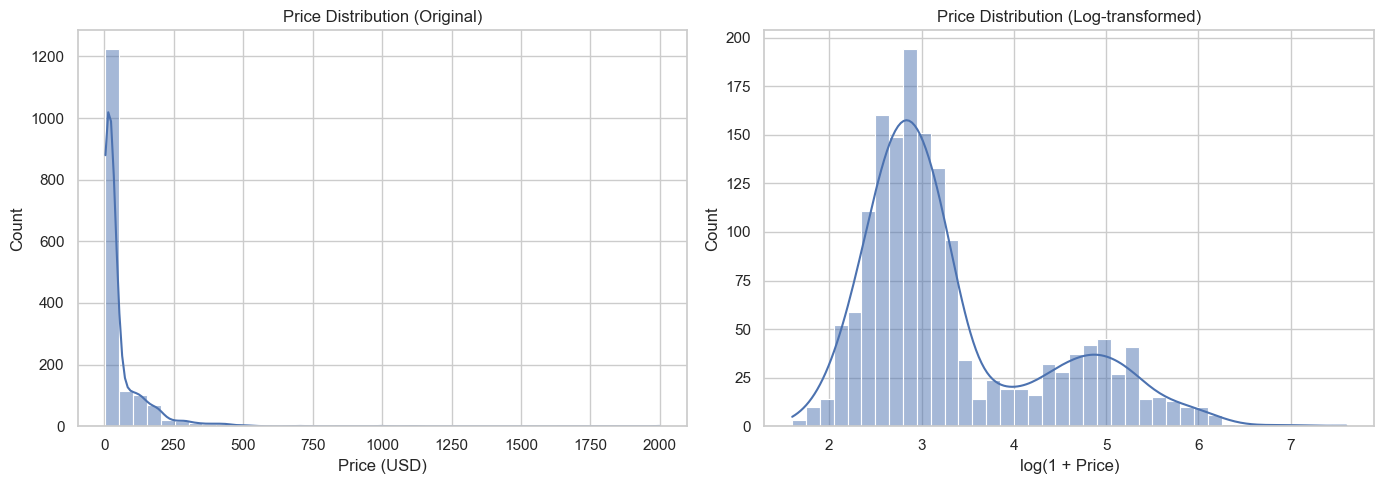

In [1007]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_price_model['price'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution (Original)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(df_price_model['price']), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Price Distribution (Log-transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

In [1008]:
print(df_price_model['price'].describe())

print(np.log1p(df_price_model['price']).describe())

count    1583.000000
mean       52.917574
std        98.023893
min         3.950000
25%        13.000000
50%        19.000000
75%        39.995000
max      1999.000000
Name: price, dtype: float64
count    1583.000000
mean        3.323089
std         1.001008
min         1.599388
25%         2.639057
50%         2.995732
75%         3.713450
max         7.600902
Name: price, dtype: float64


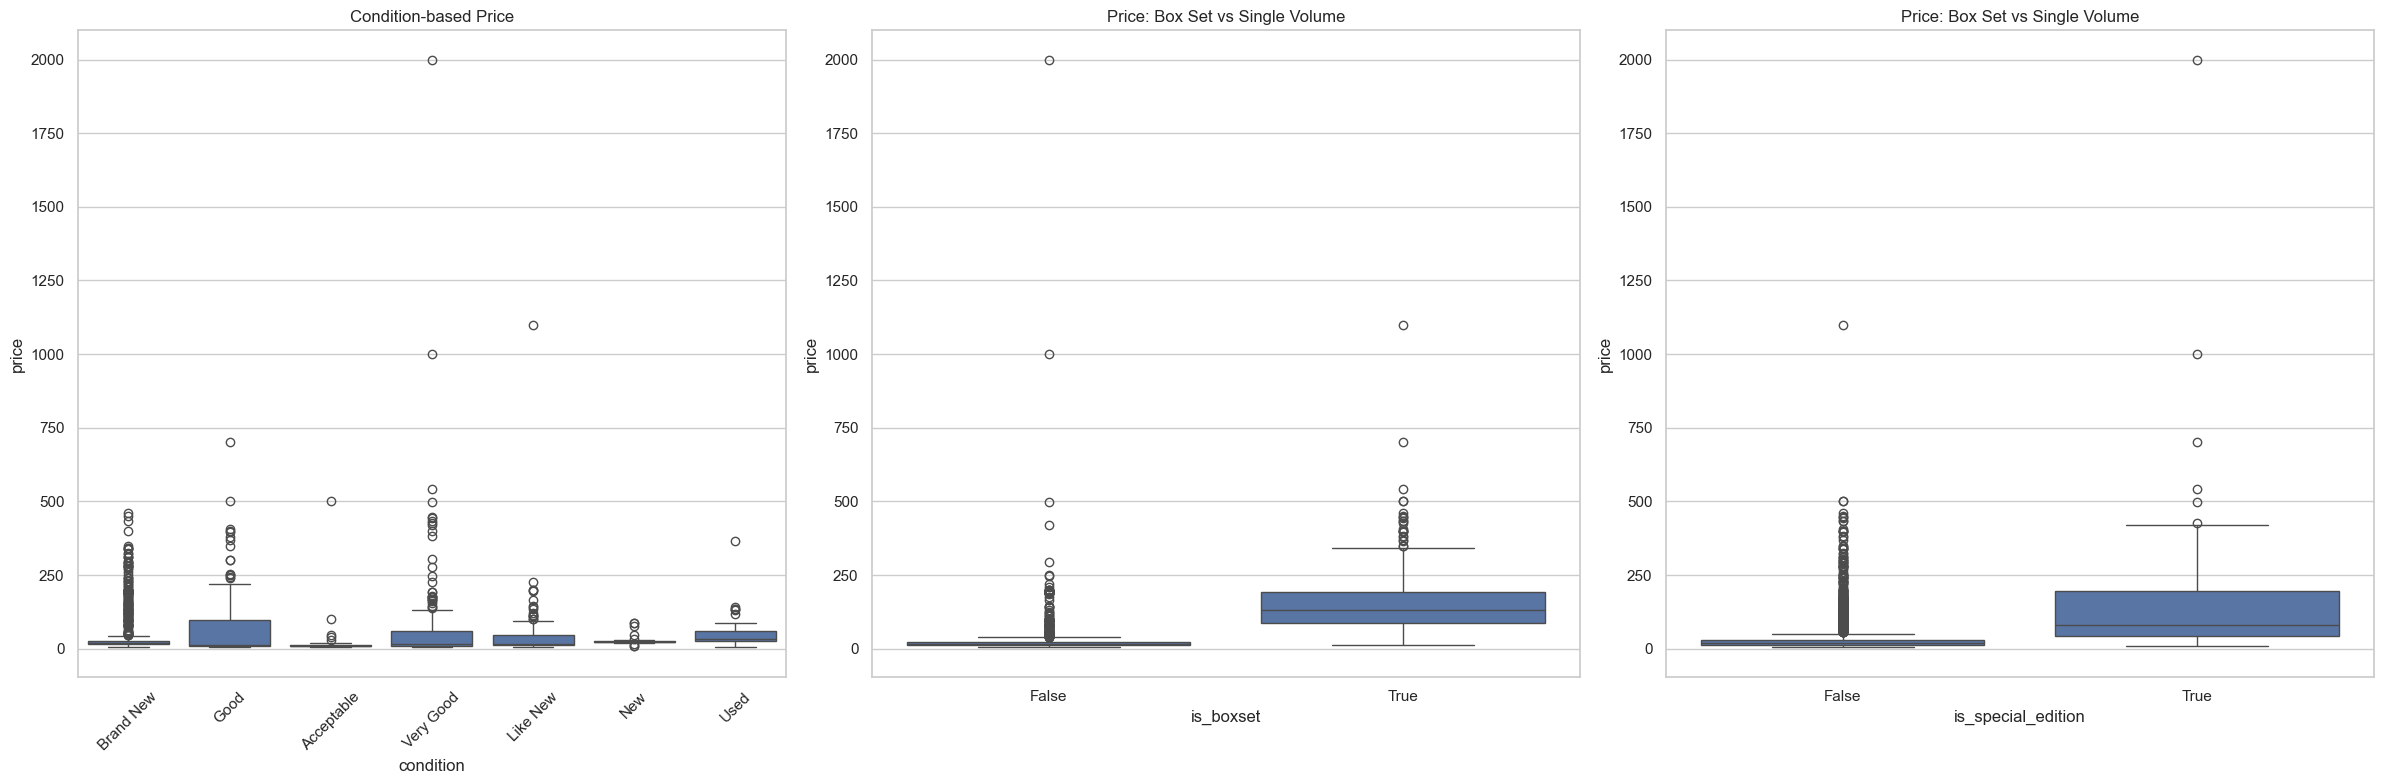

In [1009]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

sns.boxplot(data=df_price_model, x='condition', y='price', ax=axes[0])
axes[0].set_title('Condition-based Price')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df_price_model, x='is_boxset', y='price', ax=axes[1])
axes[1].set_title('Price: Box Set vs Single Volume')

sns.boxplot(data=df_price_model, x='is_special_edition', y='price', ax=axes[2])
axes[2].set_title('Price: Box Set vs Single Volume')

plt.tight_layout()
plt.show()

In [1010]:
df_price_model[df_price_model['price'] > 250].head(5)

,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,total_risk_score,risk_category,volume_confidence,volume_tier,volume_tier_encoded,condition_encoded
28,v1|125075935916|429071507693,Re:Zero: Starting Life in Another World Vol.1-...,80,11,USD,Brand New,JP,True,False,False,False,458.88,10.429091,1.0,44.0,44.0,0,0,Low Risk,high,4,4,7
36,v1|126470107965|0,Overlord Japanese Light Novel set Vol.1-16 Wit...,70,10,USD,Very Good,JP,True,False,False,False,435.00,27.187500,1.0,16.0,16.0,0,0,Low Risk,high,4,4,4
39,v1|126539862874|0,Mushoku Tensei Jobless Reincarnation Vol.1-26 ...,78,11,USD,Very Good,JP,True,False,False,False,447.08,17.195385,1.0,26.0,26.0,0,0,Low Risk,high,4,4,4
66,v1|127898400680|0,Classroom of the Elite Light Novel Complete Se...,78,13,USD,Brand New,US,True,False,True,False,449.99,40.908182,1.0,11.0,11.0,0,0,Low Risk,medium,3,3,7
69,v1|127923441558|0,1st Print 2009 Sword Art Online Vol.1-29 Japan...,79,13,USD,Good,JP,True,True,False,False,700.00,24.137931,1.0,29.0,29.0,0,0,Low Risk,high,4,4,3


In [1011]:
for col in ['condition', 'seller_location']:
    print(f"{col}: {df_price_model[col].nunique()} kategori unik")
    print(df_price_model[col].value_counts())
    print()

condition: 7 kategori unik
condition
Brand New     743
Good          319
Very Good     224
Like New      132
New            82
Acceptable     42
Used           41
Name: count, dtype: int64

seller_location: 7 kategori unik
seller_location
US    1153
JP     268
MY      71
GB      45
AU      42
CA       3
DE       1
Name: count, dtype: int64



Drop after encoding is done

In [1012]:
df_price_model = df_price_model.drop(columns='condition')

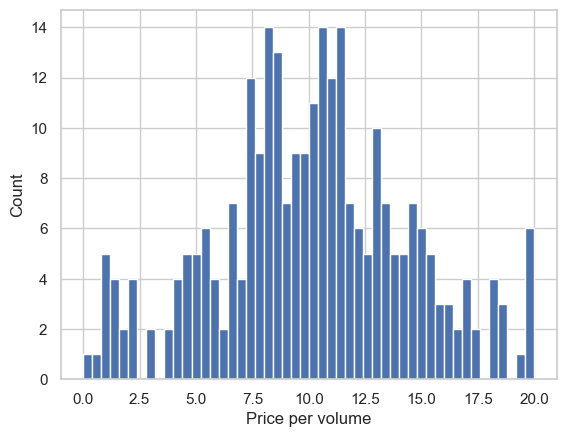

In [1013]:
import matplotlib.pyplot as plt

df_multi = df_price_model[df_price_model['volume_count'] > 1].copy()
df_multi['price_per_volume'] = df_multi['price'] / df_multi['volume_count']

plt.hist(df_multi['price_per_volume'], bins=50, range=(0, 20))
plt.xlabel('Price per volume')
plt.ylabel('Count')
# plt.axvline(x=???, color='red')  # mark candidate threshold once you see the shape
plt.show()

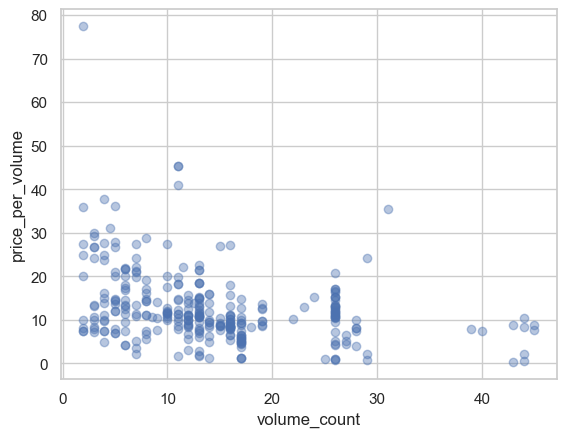

In [1014]:
plt.scatter(df_multi['volume_count'], df_multi['price_per_volume'], alpha=0.4)
plt.xlabel('volume_count')
plt.ylabel('price_per_volume')
# plt.yscale('log')  # helps see the near-zero cluster separate from the realistic cluster
plt.show()

#### A.4 Final Filtering

In [1015]:
# IQR computed only within the high-volume_count subset, not the whole dataset
high_vc = df_multi[df_multi['volume_count'] >= 20]['price_per_volume']
q1, q3 = high_vc.quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, lower_bound={lower_bound:.2f}")

Q1=6.16, Q3=13.09, IQR=6.93, lower_bound=-4.24


In [1016]:
bulk_lot_mask = (df_price_model['volume_count'] >= 5) & (df_price_model['price_per_volume'] < 4.4)

print(f"Total rows before exclusion: {len(df_price_model)}")
print(f"Rows matching bulk-lot ambiguous pattern (volume_count >= 20, price_per_volume < 5): {bulk_lot_mask.sum()}")

# Exclude them for this test
df_price_model = df_price_model[~bulk_lot_mask].copy()

print(f"Rows after exclusion: {len(df_price_model)}")

Total rows before exclusion: 1583
Rows matching bulk-lot ambiguous pattern (volume_count >= 20, price_per_volume < 5): 18
Rows after exclusion: 1565


### B. Modelling & Building Pipeline

In [1017]:
import numpy as np

def calculate_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    # Avoid division by zero when both y_true and y_pred are 0
    epsilon = 1e-10
    denominator = np.where(denominator == 0, epsilon, denominator)
    
    return np.mean(np.abs(y_pred - y_true) / denominator) * 100

#### B.1 Data Splitting & Scikit Library

In [1018]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils.class_weight import compute_sample_weight

numeric_features = [
    'title_length', 
    'title_word_count', 
    'volume_count',
    'volume_tier_encoded',
    'condition_encoded'
    
    # 'volume_number',
    # 'volume_number_end',     
    # 'total_risk_score'
]

categorical_features = [
    'currency', 
    'seller_location'
]

boolean_features = [
    'is_boxset', 
    'is_special_edition', 
    'boxset_side_story_edition_included', 
    'standalone_side_story_edition'
]

feature_cols = numeric_features + categorical_features + boolean_features
target_col = 'price'

X = df_price_model[feature_cols]
y = df_price_model[target_col]

df_meta = df_price_model[['item_id', 'title', 'is_special_edition', 'is_boxset']]

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df_price_model.index, test_size = 0.2, random_state = 42
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 1252, Test: 313


In [1019]:
X.isna().sum().sum()

np.int64(0)

In [1020]:
(X_train['volume_count'] < 0).sum()
display(X_train[X_train['volume_count'] < 0].head(5))

,title_length,title_word_count,volume_count,volume_tier_encoded,condition_encoded,currency,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition


In [1021]:
X_train.head(5)

,title_length,title_word_count,volume_count,volume_tier_encoded,condition_encoded,currency,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition
2218,68,11,1.0,1,3,USD,US,False,False,False,False
829,51,9,1.0,1,3,USD,US,False,False,False,False
1335,80,13,1.0,1,7,USD,US,False,False,False,False
1160,30,6,1.0,1,7,USD,US,False,False,False,False
2293,79,13,1.0,1,7,USD,US,False,False,False,False


In [1022]:
X_train.isna().sum()

title_length                          0
title_word_count                      0
volume_count                          0
volume_tier_encoded                   0
condition_encoded                     0
currency                              0
seller_location                       0
is_boxset                             0
is_special_edition                    0
boxset_side_story_edition_included    0
standalone_side_story_edition         0
dtype: int64

In [1023]:
X_test.isna().sum()

title_length                          0
title_word_count                      0
volume_count                          0
volume_tier_encoded                   0
condition_encoded                     0
currency                              0
seller_location                       0
is_boxset                             0
is_special_edition                    0
boxset_side_story_edition_included    0
standalone_side_story_edition         0
dtype: int64

In [1024]:
np.sum(df_price_model[df_price_model['price'] < 0])

0

In [1025]:
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

#### B.2 Final Look at X_Train

In [1026]:
X_train.head(5)

,title_length,title_word_count,volume_count,volume_tier_encoded,condition_encoded,currency,seller_location,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition
2218,68,11,1.0,1,3,USD,US,False,False,False,False
829,51,9,1.0,1,3,USD,US,False,False,False,False
1335,80,13,1.0,1,7,USD,US,False,False,False,False
1160,30,6,1.0,1,7,USD,US,False,False,False,False
2293,79,13,1.0,1,7,USD,US,False,False,False,False


#### B.3 Pipeline Modify

In [1027]:
# categorical_features = ["condition_encoded" if item == "condition_encoded" else item for item in categorical_features]
# categorical_features = ["volume_tier_encoded" if item == "volume_tier_encoded" else item for item in categorical_features]

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output = False), categorical_features),
        ('bool', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), boolean_features)
    ], remainder = 'passthrough'
)

In [1028]:
def change_model(model_reggressor, verbose:int):
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       
        inverse_func=np.expm1 
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('scale', RobustScaler(with_centering=False)), 
        ('regressor', model)
    ])
    
    baseline_pipeline.fit(X_train, y_train)
    y_pred = baseline_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    smape = calculate_smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"R^2     : {r2:.3f}")
    print(f"MAE     : {mae:.2f}")
    print(f"RMSE    : {rmse:.2f}")
    print(f"MAPE    : {mape:.3f}")
    print(f"SMAPE   : {smape:.3f}")

    results = pd.DataFrame({
        'item_id': df_meta.loc[indices_test, 'item_id'],
        'title': df_meta.loc[indices_test, 'title'],
        'is_boxset': df_meta.loc[indices_test, 'is_boxset'],
        'is_special_edition': df_meta.loc[indices_test, 'is_special_edition'],
        'volume_count': X_test['volume_count'],
        'Actual': y_test.values,
        'Predicted': y_pred
    }, index=indices_test)

    results['Residual'] = results['Actual'] - results['Predicted']
    results['Abs_Error'] = np.abs(results['Residual'])
    results['APE (%)'] = (results['Abs_Error'] / results['Actual']) * 100 

    # display 10 biggest error
    import matplotlib.pyplot as plt

    if verbose == 1:
        display(results.sort_values(by='Abs_Error', ascending=False))
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Actual vs Predicted
        axes[0].scatter(results['Actual'], results['Predicted'], alpha=0.5, color='blue')
        axes[0].plot([results['Actual'].min(), results['Actual'].max()], 
                    [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2) # Line 45 derajat
        axes[0].set_xlabel('Actual')
        axes[0].set_ylabel('Predicted')
        axes[0].set_title('Actual vs Predicted')

        # Plot 2: Residual Plot
        axes[1].scatter(results['Predicted'], results['Residual'], alpha=0.5, color='purple')
        axes[1].axhline(y=0, color='r', linestyle='--')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Residual (Actual - Predicted)')
        axes[1].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

        # display(X_train.head(5))

    return baseline_pipeline

#### B.4 Model Performance

##### B.4.1 Linear Regression

In [1029]:
lrr = change_model(LinearRegression(), 0)

R^2     : 0.519
MAE     : 15.87
RMSE    : 41.33
MAPE    : 0.386
SMAPE   : 32.551


In [1030]:
def diagnose(location:list):
    for i in range(len(location)):
        display(X_test.iloc[[location[i]]])

##### B.4.2 Random Forest Regressor

In [1031]:
rfr = change_model(RandomForestRegressor(random_state = 42, n_jobs = -1 ), 0)

R^2     : 0.724
MAE     : 13.93
RMSE    : 31.30
MAPE    : 0.403
SMAPE   : 30.601


##### B.4.3 XGBoost

R^2     : 0.739
MAE     : 11.88
RMSE    : 30.46
MAPE    : 0.299
SMAPE   : 26.920


,item_id,title,is_boxset,is_special_edition,volume_count,Actual,Predicted,Residual,Abs_Error,APE (%)
2040,v1|396289360796|0,Overlord Japanese Light Novel set Vol.1-15 Wit...,True,False,15.0,405.65,122.684181,282.965819,282.965819,69.756149
1207,v1|307070837046|0,Classroom Of The Elite Year 2 Volume 1 2 3 4 4...,False,False,1.0,249.99,12.164109,237.825891,237.825891,95.134162
322,v1|166977017979|0,Classroom of the Elite (Light Novel) Vol. 2 [P...,False,False,1.0,185.23,19.440697,165.789303,165.789303,89.504564
1201,v1|307058596683|0,Re:Zero-Starting Life in Another World Full Se...,True,False,26.0,349.59,211.288345,138.301655,138.301655,39.561101
1170,v1|306661028154|606525292043,Re:Zero-Starting Life in Another World Light N...,True,False,26.0,119.29,219.970947,-100.680947,100.680947,84.400157
...,...,...,...,...,...,...,...,...,...,...
1712,v1|365586106953|0,The Eminence in Shadow #5 (Yen Press 2022),False,False,1.0,12.26,12.253038,0.006962,0.006962,0.056783
1952,v1|388377496192|0,Ascendance of a Bookworm: Part 1 Volume 3 (Lig...,False,False,1.0,13.85,13.854778,-0.004778,0.004778,0.034500
1131,v1|298543963276|0,Ascendance of a Bookworm: Part 5 Volume 1 (Lig...,False,False,1.0,18.02,18.020004,-0.000004,0.000004,0.000024
1489,v1|357459174139|0,Re:Zero-Starting Life in Another World Volume ...,False,False,1.0,28.99,28.990004,-0.000004,0.000004,0.000012


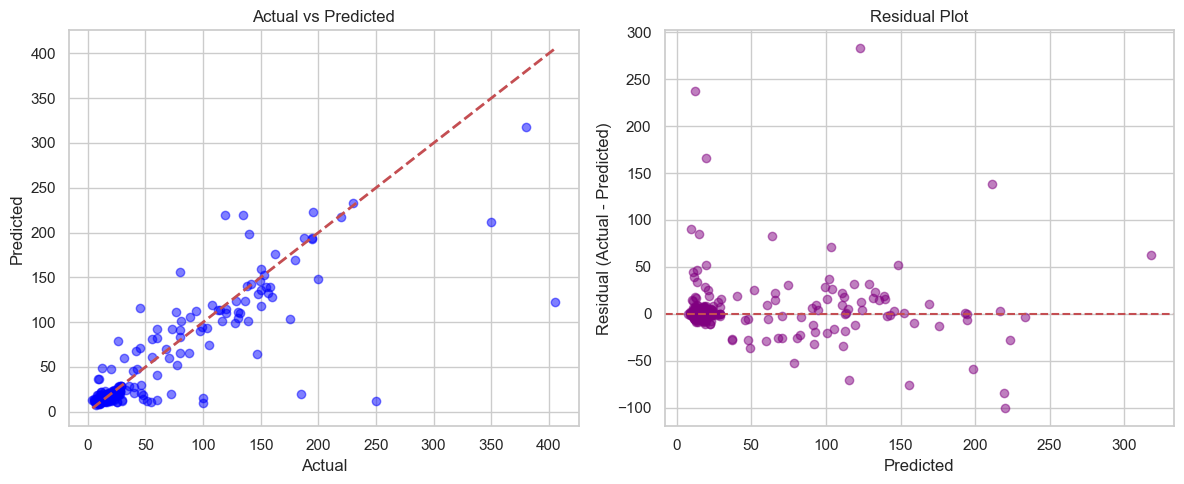

In [1032]:
XGBr = change_model(XGBRegressor(random_state=42, tree_method = 'hist', objective='reg:absoluteerror', n_jobs = -1), 1)

##### B.4.4 SVR

In [1033]:
from sklearn.svm import SVR
svr = change_model(SVR(kernel='rbf'), 0)

R^2     : 0.674
MAE     : 13.40
RMSE    : 34.03
MAPE    : 0.312
SMAPE   : 29.735


#### B.5 Diagnosing Noisy Filtering

In [1034]:
thresholds = [2, 3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.5, 4.6, 4.8, 5.0, 6]
results = []

def change_model2(model_reggressor, verbose:int):
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       
        inverse_func=np.expm1 
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('scale', RobustScaler(with_centering=False)), 
        ('regressor', model)
    ])
    
    baseline_pipeline.fit(X_train, y_train)
    y_pred = baseline_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    smape = calculate_smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # print(f"R^2     : {r2:.3f}")
    # print(f"MAE     : {mae:.2f}")
    # print(f"RMSE    : {rmse:.2f}")
    # print(f"MAPE    : {mape:.3f}")
    # print(f"SMAPE   : {smape:.3f}")

    results = pd.DataFrame({
        'item_id': df_meta.loc[indices_test, 'item_id'],
        'title': df_meta.loc[indices_test, 'title'],
        'is_boxset': df_meta.loc[indices_test, 'is_boxset'],
        'is_special_edition': df_meta.loc[indices_test, 'is_special_edition'],
        'volume_count': X_test['volume_count'],
        'Actual': y_test.values,
        'Predicted': y_pred
    }, index=indices_test)

    results['Residual'] = results['Actual'] - results['Predicted']
    results['Abs_Error'] = np.abs(results['Residual'])
    results['APE (%)'] = (results['Abs_Error'] / results['Actual']) * 100 

    import matplotlib.pyplot as plt

    if verbose == 1:
        # display 10 biggest error
        display(results.sort_values(by='Abs_Error', ascending=False))

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Actual vs Predicted
        axes[0].scatter(results['Actual'], results['Predicted'], alpha=0.5, color='blue')
        axes[0].plot([results['Actual'].min(), results['Actual'].max()], 
                    [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2) # Line 45 derajat
        axes[0].set_xlabel('Actual')
        axes[0].set_ylabel('Predicted')
        axes[0].set_title('Actual vs Predicted')

        # Plot 2: Residual Plot
        axes[1].scatter(results['Predicted'], results['Residual'], alpha=0.5, color='purple')
        axes[1].axhline(y=0, color='r', linestyle='--')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Residual (Actual - Predicted)')
        axes[1].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

        # display(X_train.head(5))

    return r2, mae, smape, baseline_pipeline

for t in thresholds:
    mask = (df_price_model['volume_count'] >= 5) & (df_price_model['price_per_volume'] < t)
    df_test = df_price_model[~mask].copy()

    numeric_features = [
    'title_length', 
    'title_word_count', 
    'volume_count',
    'volume_tier_encoded',
    'condition_encoded'
    
    # 'volume_number',
    # 'volume_number_end',     
    # 'total_risk_score'
    ]

    categorical_features = [
        'currency', 
        'seller_location'
    ]

    boolean_features = [
        'is_boxset', 
        'is_special_edition', 
        'boxset_side_story_edition_included', 
        'standalone_side_story_edition'
    ]

    feature_cols = numeric_features + categorical_features + boolean_features
    target_col = 'price'

    X = df_test[feature_cols]
    y = df_test[target_col]

    df_meta = df_test[['item_id', 'title', 'is_special_edition', 'is_boxset']]

    X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
        X, y, df_test.index, test_size = 0.2, random_state = 42
    )

    xgb_r2, xgb_mae, xgb_smape, XGB2 = change_model2(XGBRegressor(random_state = 42, objective='reg:absoluteerror', tree_method = 'hist', n_jobs = -1), 0)
    lr_r2, lr_mae, lr_smape, LR2 = change_model2(LinearRegression(), 0)
    rfr_r2, rfr_mae, rfr_smape, RFR2 = change_model2(RandomForestRegressor(random_state=42, n_jobs=-1), 0)

    print(f"{t}: Train: {len(X_train)}, Test: {len(X_test)}")
    
    results.append({'threshold': t, 'xgb_r2': xgb_r2, 'rfr_r2': rfr_r2, 'lr_r2': lr_r2, 'xgb_mae': xgb_mae, 'rfr_mae': rfr_mae, 'lr_mae': lr_mae, 'xgb_smape': xgb_smape, 'rfr_smape': rfr_smape, 'lr_smape': lr_smape, 'n_excluded': mask.sum()})

results_df = pd.DataFrame(results)

2: Train: 1252, Test: 313
3.0: Train: 1252, Test: 313
3.2: Train: 1252, Test: 313
3.4: Train: 1252, Test: 313
3.6: Train: 1252, Test: 313
3.8: Train: 1252, Test: 313
4.0: Train: 1252, Test: 313
4.2: Train: 1252, Test: 313
4.4: Train: 1252, Test: 313
4.5: Train: 1250, Test: 313
4.6: Train: 1249, Test: 313
4.8: Train: 1248, Test: 312
5.0: Train: 1247, Test: 312
6: Train: 1236, Test: 310


In [1035]:
results_df

,threshold,xgb_r2,rfr_r2,lr_r2,xgb_mae,rfr_mae,lr_mae,xgb_smape,rfr_smape,lr_smape,n_excluded
0,2.0,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
1,3.0,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
2,3.2,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
3,3.4,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
4,3.6,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
5,3.8,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
6,4.0,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
7,4.2,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
8,4.4,0.738668,0.724040,0.518982,11.884631,13.926889,15.872707,26.920101,30.600694,32.550850,0
9,4.5,0.687367,0.646048,0.620366,13.398497,14.897771,15.911840,27.761711,30.843659,32.717004,2


#### B.6 Hyperparameter Tuning

In [1036]:
from sklearn.model_selection import GridSearchCV

xgbr_base = XGBRegressor(random_state=42, tree_method = 'hist', objective='reg:absoluteerror', n_jobs = -1)

# 2. Re-create your TransformedTargetRegressor and Pipeline using the base model
model_wrapper = TransformedTargetRegressor(
    regressor=xgbr_base,
    func=np.log1p,
    inverse_func=np.expm1
)

tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scale', RobustScaler(with_centering=False)),
    ('regressor', model_wrapper)
])


param_grid = {
    'regressor__regressor__max_depth': [5, 6, 7, 15],
    'regressor__regressor__learning_rate': [0.01, 0.02, 0.05],
    'regressor__regressor__subsample': [0.8, 0.9, 1.0],
    'regressor__regressor__colsample_bytree': [0.8, 0.9, 1.0],
    'regressor__regressor__objective': ['reg:squarederror', 'reg:absoluteerror', 'reg:gamma', 'reg:tweedie']
}

grid_search = GridSearchCV(
    estimator=XGBr,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

print("Starting grid search...")
grid_search.fit(X_train, y_train)

# 6. Extract and evaluate the best model
print("\nBest Parameters Found:")
print(grid_search.best_params_)

best_pipeline = grid_search.best_estimator_
y_pred_tuned = best_pipeline.predict(X_test)

Starting grid search...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters Found:
{'regressor__regressor__colsample_bytree': 0.8, 'regressor__regressor__learning_rate': 0.05, 'regressor__regressor__max_depth': 7, 'regressor__regressor__objective': 'reg:absoluteerror', 'regressor__regressor__subsample': 0.9}


In [1037]:
"""
CV diagnostics — jalankan setelah grid_search.fit(X_train, y_train)
Tujuan: lihat variance antar fold untuk parameter terbaik, bukan cuma mean.
"""
# ------------------------------------------------------------------
# 1. Ambil cv_results_ sebagai DataFrame
# ------------------------------------------------------------------
cv_results = pd.DataFrame(grid_search.cv_results_)

# ------------------------------------------------------------------
# 2. Fokus ke baris param terbaik (rank_test_score == 1)
# ------------------------------------------------------------------
best_row = cv_results[cv_results['rank_test_score'] == 1].iloc[0]

# Ambil semua kolom split*_test_score untuk baris ini
split_score_cols = [c for c in cv_results.columns if c.startswith('split') and c.endswith('_test_score')]
fold_scores = best_row[split_score_cols].values.astype(float)

print("=== Best Params ===")
print(best_row['params'])
print()

print("=== Per-Fold Scores (scoring metric yang dipakai di GridSearchCV) ===")
for i, score in enumerate(fold_scores):
    print(f"  Fold {i}: {score:.4f}")

print()
print(f"Mean : {fold_scores.mean():.4f}")
print(f"Std  : {fold_scores.std():.4f}")
print(f"Min  : {fold_scores.min():.4f}")
print(f"Max  : {fold_scores.max():.4f}")
print(f"Range (max-min): {fold_scores.max() - fold_scores.min():.4f}")

# ------------------------------------------------------------------
# 3. Bandingkan top-5 kombinasi param — apakah rank 1 benar2 unggul
#    atau cuma menang tipis dalam noise band std-nya sendiri?
# ------------------------------------------------------------------
print("\n=== Top 5 Param Combinations (mean vs std) ===")
top5 = cv_results.nsmallest(5, 'rank_test_score')[
    ['rank_test_score', 'mean_test_score', 'std_test_score', 'params']
]
print(top5.to_string(index=False))

# ------------------------------------------------------------------
# 4. Overlap check: apakah rank-1 mean masih di dalam
#    mean ± std kombinasi rank-2, rank-3, dst?
#    Kalau overlap, "yang terbaik" itu sebenarnya tidak signifikan beda.
# ------------------------------------------------------------------
best_mean = best_row['mean_test_score']
best_std = best_row['std_test_score']
print(f"\nBest param band: [{best_mean - best_std:.4f}, {best_mean + best_std:.4f}]")
print("Apakah param lain overlap dengan band ini? (kalau ya -> selisih 'terbaik' cuma noise)")
for idx, row in top5.iterrows():
    if row['rank_test_score'] == 1:
        continue
    lo, hi = row['mean_test_score'] - row['std_test_score'], row['mean_test_score'] + row['std_test_score']
    overlap = not (hi < (best_mean - best_std) or lo > (best_mean + best_std))
    print(f"  Rank {int(row['rank_test_score'])}: band=[{lo:.4f}, {hi:.4f}] -> overlap dgn best: {overlap}")

# ------------------------------------------------------------------
# 5. (Opsional tapi disarankan) Bandingkan juga distribusi actual y
#    per fold, untuk lihat apakah outlier (box set/special edition
#    mahal) numpuk di satu fold tertentu.
#    Perlu cv splitter yang sama dengan yang dipakai grid_search.
# ------------------------------------------------------------------
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    y_val_fold = y_train.iloc[val_idx]
    print(f"Fold {i}: n={len(y_val_fold)}, mean_price={y_val_fold.mean():.2f}, "
          f"max_price={y_val_fold.max():.2f}, price>200 count={(y_val_fold>200).sum()}")

=== Best Params ===
{'regressor__regressor__colsample_bytree': 0.8, 'regressor__regressor__learning_rate': 0.05, 'regressor__regressor__max_depth': 7, 'regressor__regressor__objective': 'reg:absoluteerror', 'regressor__regressor__subsample': 0.9}

=== Per-Fold Scores (scoring metric yang dipakai di GridSearchCV) ===
  Fold 0: -11.8533
  Fold 1: -15.0023
  Fold 2: -19.2656
  Fold 3: -15.1133
  Fold 4: -18.4102

Mean : -15.9289
Std  : 2.6617
Min  : -19.2656
Max  : -11.8533
Range (max-min): 7.4123

=== Top 5 Param Combinations (mean vs std) ===
 rank_test_score  mean_test_score  std_test_score                                                                                                                                                                                                                              params
               1       -15.928930        2.661748  {'regressor__regressor__colsample_bytree': 0.8, 'regressor__regressor__learning_rate': 0.05, 'regressor__regressor__max_dep

In [1038]:
##### B.5.1 Result
tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_mape = mean_absolute_percentage_error(y_test, y_pred_tuned)
tuned_smape = calculate_smape(y_test, y_pred_tuned)

print("\n--- Tuned XGBoost Metrics ---")
print(f"R^2     : {tuned_r2:.3f}")
print(f"MAE     : {tuned_mae:.2f}")
print(f"RMSE    : {tuned_rmse:.2f}")
print(f"MAPE    : {tuned_mape:.3f}")
print(f"SMAPE    : {tuned_smape:.3f}")


--- Tuned XGBoost Metrics ---
R^2     : 0.285
MAE     : 19.96
RMSE    : 112.98
MAPE    : 0.266
SMAPE    : 25.808


### C. Final Model Inspection

In [1039]:
XGBr

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['title_length','title_word_count','volume_count',...,'is_special_edition', 'boxset_side_story_edition_included','standalone_side_story_edition']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('bool', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the 

#### C.1 Feature Importance from Model

In [1040]:
fitted_ttr = XGBr.named_steps['regressor']   # TransformedTargetRegressor
xgb_model = fitted_ttr.regressor_  

print("Model type:", type(xgb_model))
print("Booster:", xgb_model.get_booster())

preprocessor_fitted = XGBr.named_steps['preprocessor']
feature_names_after_ct = preprocessor_fitted.get_feature_names_out()
 
# Bersihkan prefix yang ditambahkan ColumnTransformer (cat__, remainder__, dst)
clean_feature_names = [
    name.split('__', 1)[-1] if '__' in name else name
    for name in feature_names_after_ct
]

print(f"\nTotal fitur setelah encoding: {len(clean_feature_names)}")

Model type: <class 'xgboost.sklearn.XGBRegressor'>
Booster: <xgboost.core.Booster object at 0x0000022D5DB96F60>

Total fitur setelah encoding: 17


In [1041]:
booster = xgb_model.get_booster()

importance_types = ['gain', 'weight', 'cover']
importance_dict = {}
 
for imp_type in importance_types:
    raw_scores = booster.get_score(importance_type=imp_type)
    # raw_scores contoh: {'f0': 12.3, 'f5': 8.1, ...} -- fitur yang TIDAK PERNAH
    # dipakai untuk split tidak akan muncul di dict ini sama sekali
    mapped_scores = {}
    for fkey, score in raw_scores.items():
        idx = int(fkey.replace('f', ''))
        if idx < len(clean_feature_names):
            mapped_scores[clean_feature_names[idx]] = score
    importance_dict[imp_type] = mapped_scores
 
# ------------------------------------------------------------------
# 4. Gabungkan jadi satu DataFrame untuk perbandingan
# ------------------------------------------------------------------
importance_df = pd.DataFrame(importance_dict).fillna(0)
importance_df = importance_df.sort_values('gain', ascending=False)
 
# Normalisasi tiap kolom ke persentase supaya lebih mudah dibaca relatif
importance_df_pct = importance_df.copy()
for col in importance_df_pct.columns:
    total = importance_df_pct[col].sum()
    if total > 0:
        importance_df_pct[col] = (importance_df_pct[col] / total * 100).round(2)
 
print("\n=== Feature Importance (gain, weight, cover) — sorted by gain ===")
print(importance_df_pct.to_string())


=== Feature Importance (gain, weight, cover) — sorted by gain ===
                                          gain  weight  cover
seller_location_MY                       63.56    0.67   8.12
is_boxset_True                            5.92    1.89   6.53
volume_tier_encoded                       5.35    8.02   2.76
title_word_count                          4.65   14.85   9.28
seller_location_US                        3.12    2.53   2.02
seller_location_JP                        2.55    2.93  15.39
seller_location_DE                        2.41    2.93  19.30
boxset_side_story_edition_included_True   2.14    0.85   7.95
standalone_side_story_edition_True        1.94   40.36   2.15
is_special_edition_True                   1.91    2.30   6.52
seller_location_GB                        1.89    3.04   1.46
seller_location_CA                        1.59    0.67  11.93
seller_location_AU                        1.58    0.52   3.16
title_length                              1.40   18.42   3.42


In [1042]:
used_features = set(importance_df.index)
all_features = set(clean_feature_names)
unused_features = all_features - used_features
 
print(f"\n=== Fitur yang TIDAK PERNAH dipakai untuk split ({len(unused_features)}) ===")
for f in sorted(unused_features):
    print(f"  - {f}")
print("(Ini kandidat untuk di-drop dari pipeline -- termasuk kemungkinan besar text_risk_score)")


=== Fitur yang TIDAK PERNAH dipakai untuk split (3) ===
  - condition_encoded
  - currency_USD
  - volume_count
(Ini kandidat untuk di-drop dari pipeline -- termasuk kemungkinan besar text_risk_score)


In [1043]:
# ------------------------------------------------------------------
# 6. Top 15 fitur by gain -- yang paling worth didiskusikan/didokumentasikan
# ------------------------------------------------------------------
print("\n=== Top 15 Features by Gain ===")
print(importance_df_pct[['gain']].head(15).to_string())
 



=== Top 15 Features by Gain ===
                                          gain
seller_location_MY                       63.56
is_boxset_True                            5.92
volume_tier_encoded                       5.35
title_word_count                          4.65
seller_location_US                        3.12
seller_location_JP                        2.55
seller_location_DE                        2.41
boxset_side_story_edition_included_True   2.14
standalone_side_story_edition_True        1.94
is_special_edition_True                   1.91
seller_location_GB                        1.89
seller_location_CA                        1.59
seller_location_AU                        1.58
title_length                              1.40


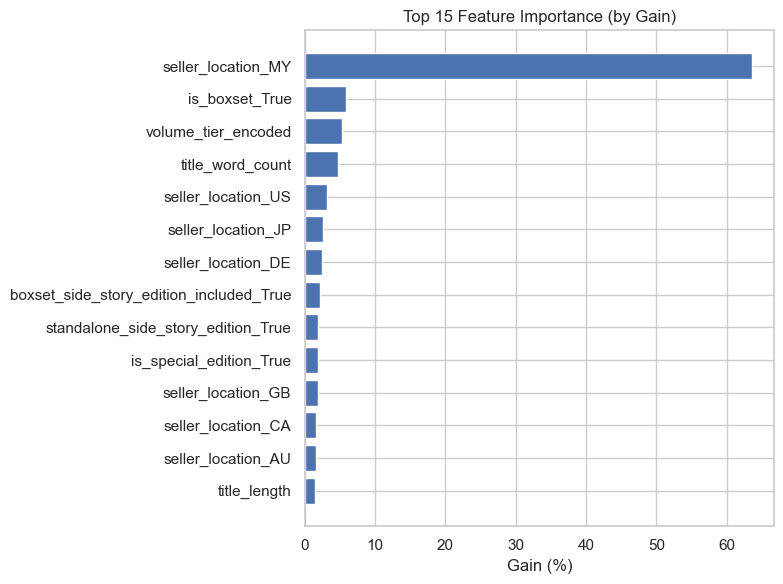

In [1044]:
# ------------------------------------------------------------------
# 7. (Opsional) Plot -- kalau mau visual cepat di notebook
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
top_n = importance_df_pct.head(15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_n.index[::-1], top_n['gain'][::-1])
ax.set_xlabel('Gain (%)')
ax.set_title('Top 15 Feature Importance (by Gain)')
plt.tight_layout()
plt.show()

US seller location is too high


In [1045]:
# ------------------------------------------------------------------
# 1. Distribusi jumlah listing per seller_location
#    -> ini yang akan konfirmasi/bantah hipotesis class imbalance
# ------------------------------------------------------------------
df = df_price_model.copy()

print("=== Distribusi Jumlah Listing per seller_location ===")
location_counts = df['seller_location'].value_counts()
location_pct = (location_counts / len(df) * 100).round(2)
dist_df = pd.DataFrame({'count': location_counts, 'pct': location_pct})
print(dist_df.to_string())

=== Distribusi Jumlah Listing per seller_location ===
                 count    pct
seller_location              
US                1149  73.42
JP                 261  16.68
MY                  64   4.09
GB                  45   2.88
AU                  42   2.68
CA                   3   0.19
DE                   1   0.06


In [1046]:
# ------------------------------------------------------------------
# 2. Rata-rata & median price per lokasi
#    -> kalau US punya mean/median jauh beda dari lokasi lain, itu
#       alasan legit kenapa gain tinggi. Kalau mirip-mirip semua,
#       curigai lokasi cuma proxy variabel lain.
# ------------------------------------------------------------------
print("\n=== Price Statistics per seller_location ===")
price_stats = df.groupby('seller_location')['price'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2).sort_values('count', ascending=False)
print(price_stats.to_string())


=== Price Statistics per seller_location ===
                 count    mean  median     std    min      max
seller_location                                               
US                1149   28.80   15.97   55.42   3.95  1099.99
JP                 261  137.12  108.00  165.88   5.00  1999.00
MY                  64  187.07  190.70  109.23  25.99   399.99
GB                  45   23.94   24.65    3.52  18.02    29.15
AU                  42   23.77   20.35    9.78  15.24    49.43
CA                   3   35.62   21.51   34.85  10.04    75.32
DE                   1   46.10   46.10     NaN  46.10    46.10


In [1047]:
# ------------------------------------------------------------------
# 3. Confounding check: apakah US vs non-US berkorelasi dengan
#    fitur lain yang sudah ada di top gain (condition, is_special_edition,
#    is_boxset, volume_count)?
# ------------------------------------------------------------------
df['is_us'] = (df['seller_location'] == 'US')
 
print("\n=== Confounding Check: is_us vs fitur lain ===")
 
if 'condition' in df.columns:
    print("\n-- condition distribution (US vs non-US) --")
    print(pd.crosstab(df['is_us'], df['condition'], normalize='index').round(3).to_string())
 
if 'is_special_edition' in df.columns:
    print("\n-- is_special_edition rate (US vs non-US) --")
    print(df.groupby('is_us')['is_special_edition'].mean().round(3).to_string())
 
if 'is_boxset' in df.columns:
    print("\n-- is_boxset rate (US vs non-US) --")
    print(df.groupby('is_us')['is_boxset'].mean().round(3).to_string())
 
if 'volume_count' in df.columns:
    print("\n-- volume_count mean (US vs non-US) --")
    print(df.groupby('is_us')['volume_count'].mean().round(3).to_string())


=== Confounding Check: is_us vs fitur lain ===

-- is_special_edition rate (US vs non-US) --
is_us
False    0.135
True     0.033

-- is_boxset rate (US vs non-US) --
is_us
False    0.502
True     0.063

-- volume_count mean (US vs non-US) --
is_us
False    8.893
True     1.453


In [1048]:
# ------------------------------------------------------------------
# 4. Outlier check: apakah harga ekstrem (top 5%) numpuk di lokasi
#    tertentu (baik US maupun non-US)?
# ------------------------------------------------------------------
price_95th = df['price'].quantile(0.95)
outliers = df[df['price'] >= price_95th]
 
print(f"\n=== Distribusi seller_location untuk listing top 5% termahal (>= ${price_95th:.2f}) ===")
outlier_dist = outliers['seller_location'].value_counts()
outlier_pct = (outlier_dist / len(outliers) * 100).round(2)
print(pd.DataFrame({'count': outlier_dist, 'pct_of_outliers': outlier_pct}).to_string())
 
print(f"\nBandingkan dengan distribusi keseluruhan (baseline):")
print(dist_df.to_string())
print("\n(Kalau US persentasenya di outlier JAUH beda dari baseline keseluruhan,")
print(" itu tanda lokasi berkorelasi kuat dengan harga ekstrem -- perlu digali kenapa)")
 
# ------------------------------------------------------------------


=== Distribusi seller_location untuk listing top 5% termahal (>= $199.56) ===
                 count  pct_of_outliers
seller_location                        
JP                  32            40.51
MY                  28            35.44
US                  19            24.05

Bandingkan dengan distribusi keseluruhan (baseline):
                 count    pct
seller_location              
US                1149  73.42
JP                 261  16.68
MY                  64   4.09
GB                  45   2.88
AU                  42   2.68
CA                   3   0.19
DE                   1   0.06

(Kalau US persentasenya di outlier JAUH beda dari baseline keseluruhan,
 itu tanda lokasi berkorelasi kuat dengan harga ekstrem -- perlu digali kenapa)


In [1049]:
# ------------------------------------------------------------------
# 5. Currency check -- karena currency_USD ternyata TIDAK PERNAH
#    dipakai untuk split (dari hasil feature importance sebelumnya),
#    padahal secara intuisi currency & seller_location US harusnya
#    berkorelasi kuat. Ini worth dicek juga.
# ------------------------------------------------------------------
if 'currency' in df.columns:
    print("\n=== Currency vs seller_location (US) crosstab ===")
    print(pd.crosstab(df['is_us'], df['currency']).to_string())
    print("\n(Kalau currency HAMPIR SELALU USD baik US maupun non-US -- itu jelaskan")
    print(" kenapa currency_USD constant/tidak dipakai split, sementara seller_location")
    print(" tetap dipakai karena ada variance geografis yang currency tidak tangkap)")


=== Currency vs seller_location (US) crosstab ===
currency   USD
is_us         
False      416
True      1149

(Kalau currency HAMPIR SELALU USD baik US maupun non-US -- itu jelaskan
 kenapa currency_USD constant/tidak dipakai split, sementara seller_location
 tetap dipakai karena ada variance geografis yang currency tidak tangkap)


#### C.2 Non-SHAP inspection

In [1050]:
categorical_top_features = [
    'condition', 'is_special_edition', 'is_boxset',
    'boxset_side_story_edition_included', 'standalone_side_story_edition',
    'seller_location'
]
 
print("=== A. Mean/Median Actual Price per Kategori Fitur ===\n")
for feat in categorical_top_features:
    if feat in df_price_model.columns:
        print(f"--- {feat} ---")
        summary = df_price_model.groupby(feat)['price'].agg(['count', 'mean', 'median']).round(2)
        summary = summary.sort_values('mean', ascending=False)
        print(summary.to_string())
        print()

=== A. Mean/Median Actual Price per Kategori Fitur ===

--- is_special_edition ---
                    count    mean  median
is_special_edition                       
True                   94  153.33   80.00
False                1471   46.68   18.02

--- is_boxset ---
           count    mean  median
is_boxset                       
True         281  166.61  134.00
False       1284   28.24   16.34

--- boxset_side_story_edition_included ---
                                    count    mean  median
boxset_side_story_edition_included                       
True                                   18  143.86  113.85
False                                1547   52.03   18.52

--- standalone_side_story_edition ---
                               count   mean  median
standalone_side_story_edition                      
False                           1536  53.60   18.83
True                              29  26.04   17.77

--- seller_location ---
                 count    mean  median
seller_loca

In [1051]:
def manual_partial_dependence(pipeline, X_reference, feature_name, feature_values):
    """
    Fix semua row ke satu baseline (median numeric / mode categorical),
    lalu ubah feature_name ke tiap value di feature_values, prediksi ulang.
    Return: array prediksi (dalam dollar asli, karena lewat full pipeline
    termasuk inverse_func log1p->expm1 otomatis).
    """
    baseline_row = {}
    for col in X_reference.columns:
        if X_reference[col].dtype in ['int64', 'float64']:
            baseline_row[col] = X_reference[col].median()
        else:
            baseline_row[col] = X_reference[col].mode()[0]
 
    rows = []
    for val in feature_values:
        row = baseline_row.copy()
        row[feature_name] = val
        rows.append(row)
 
    synthetic_X = pd.DataFrame(rows)
    # Pastikan urutan kolom sama persis dengan X_reference
    synthetic_X = synthetic_X[X_reference.columns]
 
    predictions = pipeline.predict(synthetic_X)
    return predictions
 
 
print("\n=== B. Manual Partial Dependence (prediksi dalam $ asli) ===\n")
 
# --- B1. seller_location ---
locations = X_train['seller_location'].unique().tolist()
pd_preds = manual_partial_dependence(XGBr, X_train, 'seller_location', locations)
pd_result = pd.DataFrame({'seller_location': locations, 'predicted_price': pd_preds}).sort_values(
    'predicted_price', ascending=False
)
print("--- seller_location (semua fitur lain di-fix ke median/mode) ---")
print(pd_result.to_string(index=False))
print()
 
# --- B2. condition ---
if 'condition' in X_train.columns:
    conditions = X_train['condition'].dropna().unique().tolist()
    pd_preds = manual_partial_dependence(XGBr, X_train, 'condition', conditions)
    pd_result = pd.DataFrame({'condition': conditions, 'predicted_price': pd_preds}).sort_values(
        'predicted_price', ascending=False
    )
    print("--- condition ---")
    print(pd_result.to_string(index=False))
    print()
 
# --- B3. is_special_edition, is_boxset (boolean) ---
for feat in ['is_special_edition', 'is_boxset']:
    if feat in X_train.columns:
        pd_preds = manual_partial_dependence(XGBr, X_train, feat, [False, True])
        pd_result = pd.DataFrame({feat: [False, True], 'predicted_price': pd_preds})
        print(f"--- {feat} ---")
        print(pd_result.to_string(index=False))
        delta = pd_result['predicted_price'].iloc[1] - pd_result['predicted_price'].iloc[0]
        print(f"Delta (True - False): ${delta:.2f}")
        print()
 
# --- B4. volume_count (numeric) -- lihat pola non-linear/diminishing returns ---
from pathlib import Path
notebook_temp_path = Path("temps/")
notebook_temp_path.mkdir(parents = True, exist_ok = True)

if 'volume_count' in X_train.columns:
    vol_range = np.arange(1, 46, 1)  # sesuai max volume_count di data (45)
    pd_preds = manual_partial_dependence(XGBr, X_train, 'volume_count', vol_range)
 
    plt.figure(figsize=(8, 5))
    plt.plot(vol_range, pd_preds, marker='o', markersize=3)
    plt.xlabel('volume_count')
    plt.ylabel('Predicted Price ($)')
    plt.title('Manual Partial Dependence — volume_count\n(other features fixed to median/mode)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(notebook_temp_path/ 'volume_count_median_mode', dpi=120, bbox_inches='tight')
    plt.show()
 
    print("--- volume_count (lihat plot untuk pola non-linear) ---")
    print(pd.DataFrame({'volume_count': vol_range, 'predicted_price': pd_preds}).to_string(index=False))
 
# ------------------------------------------------------------------
# C. Ringkasan arah efek -- pengganti langsung untuk SHAP direction plot
# ------------------------------------------------------------------
print("\n=== C. Ringkasan Arah Efek (relatif terhadap baseline median/mode) ===")
print("Catatan: ini BUKAN pengganti sempurna SHAP -- partial dependence")
print("mengasumsikan fitur lain independen (fixed di median/mode), sementara")
print("SHAP memperhitungkan interaksi antar fitur secara individual per-row.")
print("Untuk dataset sekecil ini dengan confounding (mis. lokasi & condition")
print("mungkin berkorelasi), interpretasikan sebagai APPROXIMATE direction,")
print("bukan exact isolated causal effect.")


=== B. Manual Partial Dependence (prediksi dalam $ asli) ===



ValueError: X has 17 features, but RobustScaler is expecting 16 features as input.

#### C.3 Create Confidence Interval Prediction Model

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_cal, X_test, y_cal, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

XGBr.fit(X_train, y_train)
y_cal_pred = XGBr.predict(X_cal)
cal_scores = np.abs(np.log1p(y_cal) - np.log1p(y_cal_pred))

alpha = 0.05  # target 90% coverage
n = len(cal_scores)
q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)  # clip di 1.0 buat jaga-jaga
q_hat = np.quantile(cal_scores, q_level, method='higher')

y_test_pred = XGBr.predict(X_test)
log_pred = np.log1p(y_test_pred)
lower = np.expm1(log_pred - q_hat)
upper = np.expm1(log_pred + q_hat)

covered = np.mean((y_test >= lower) & (y_test <= upper))
print(f"Empirical coverage: {covered:.3f} (target: {1-alpha})")

Empirical coverage: 0.949 (target: 0.95)


#### D. Hypotheses Price_Per_Volume

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils.class_weight import compute_sample_weight

numeric_features = [
    'title_length', 
    'title_word_count', 
    'volume_count',
    'volume_tier_encoded',
    'condition_encoded'

    # 'volume_number',
    # 'volume_number_end',     
    # 'total_risk_score'
]

categorical_features = [
    'currency', 
    'seller_location'
]

boolean_features = [
    'is_boxset', 
    'is_special_edition', 
    'boxset_side_story_edition_included', 
    'standalone_side_story_edition'
]

feature_cols = numeric_features + categorical_features + boolean_features
target_col = 'price_per_volume'

X = df_price_model[feature_cols]
y = df_price_model[target_col]

df_meta = df_price_model[['item_id', 'title', 'is_special_edition', 'is_boxset']]

X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, df_price_model.index, test_size = 0.2, random_state = 42
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 1252, Test: 313


In [ ]:
# categorical_features = ["condition_encoded" if item == "condition_encoded" else item for item in categorical_features]
# categorical_features = ["volume_tier_encoded" if item == "volume_tier_encoded" else item for item in categorical_features]

preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output = False), categorical_features),
        ('bool', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), boolean_features)
    ], remainder = 'passthrough'
)

def change_model2(model_reggressor, verbose:int):
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       
        inverse_func=np.expm1 
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('scale', RobustScaler(with_centering=False)), 
        ('regressor', model)
    ])
    
    baseline_pipeline.fit(X_train, y_train)
    y_pred_per_vol = baseline_pipeline.predict(X_test)
    y_pred_total = y_pred_per_vol * X_test['volume_count']

    y_test_total = df_price_model.loc[indices_test, 'price'].values

    r2_reconstructed = r2_score(y_test_total, y_pred_total)
    mae_reconstructed = mean_absolute_error(y_test_total, y_pred_total)
    rmse_reconstructed = np.sqrt(mean_squared_error(y_test_total, y_pred_total))
    mape_reconstructed = mean_absolute_percentage_error(y_test_total, y_pred_total)
    smape_reconstructed = calculate_smape(y_test_total, y_pred_total)

    print("--- Reconstructed Total Price Metrics ---")
    print(f"R^2     : {r2_reconstructed:.3f}")
    print(f"MAE     : {mae_reconstructed:.2f}")
    print(f"RMSE    : {rmse_reconstructed:.2f}")
    print(f"MAPE    : {mape_reconstructed:.3f}")
    print(f"SMAPE    : {smape_reconstructed:.3f}")

    return baseline_pipeline

##### B.5.1 Linear Regression

In [ ]:
lr_2 = change_model2(LinearRegression(), 1)

--- Reconstructed Total Price Metrics ---
R^2     : 0.270
MAE     : 18.66
RMSE    : 50.89
MAPE    : 0.405
SMAPE    : 33.912


##### B.5.2 Random Forest Regression

In [ ]:
rfr_2= change_model2(RandomForestRegressor(random_state=42), 1)

--- Reconstructed Total Price Metrics ---
R^2     : -0.122
MAE     : 17.32
RMSE    : 63.11
MAPE    : 0.441
SMAPE    : 30.761


##### B.5.3 XGB Regression

In [ ]:
xgb_2 = change_model2(XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs = -1), 1)

--- Reconstructed Total Price Metrics ---
R^2     : 0.253
MAE     : 15.17
RMSE    : 51.51
MAPE    : 0.322
SMAPE    : 27.756
